# cluster specific TF-gene activaltion
#### cluster can be cell type, niche, spatial cluster etc

1. Link peaks to marker genes for clusters and to genes in gene set
    - annotate as proximal: 100-2000bp upstream TSS 
    - annotate as distal: +/- 150kbp TSS (and not proximal)
2. Identify relevant peaks for specific cluster: differs from BA
    - test for cluster: overaccessible compared to background clusters?
3. Identify TFs for which motifs are enriched in these peaks 
    - continue with 2 analysis paths: 
        - for single clusters
        - for all clusters
4. Score local footprints
    - mean(valley) - mean(flanks)
    - standard diviation in flanks/ total number of sites with Tn5 insertions in flanks



In [ ]:
library(parallel)
library(GenomicFeatures)
set.seed(1234)
library(repr)
library(motifmatchr)
library(fastmatch)
library(qlcMatrix)

library(ensembldb)
library(EnsDb.Hsapiens.v86)
library(AnnotationFilter)

library(Signac)
library(Seurat)
library(JASPAR2024)
library(TFBSTools)
library(BSgenome.Hsapiens.UCSC.hg38)
library(patchwork)
library(ggplot2)
library(Matrix)
library(zoo)
library(tidyr)

source("../multiome_methods/function_calls.r")
source("../multiome_methods/peak_gene_relations.r")
source("../multiome_methods/binding_site_identification.r")
source("../multiome_methods/binding_site_identification_parallel.r")
source("../multiome_methods/TF_activity.r")
source("../multiome_methods/signac_utils.r")

library(dplyr)

library(ggplot2)
library(hexbin)
library(RColorBrewer)
library(cowplot)
library(gridExtra)
library(ggExtra)

library(pheatmap)
library(purrr)
library(data.table)
library(Rsamtools)
library(stringi)

library(dplyr)
library(jsonlite)


Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union





Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomeInfoDb

Loading required package: GenomicRanges

Loading required package: AnnotationDbi

Loading required package: 

In [ ]:
# Parameters given by user
analysis_name = "colagen_fibril_organization"
gene_set = "GO:0030199"
cluster = "Fibroblast"
ident = "cell_type"
initial_upload = TRUE

adata_tg = "adata_tg_scores.h5ad"
global_analysis_out <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_1775635064043_mopitas/plasmidpoop/global_motif_analysis.rds")
Idents(global_analysis_out)<-indent
# combine priorGRN with seed genes and extrend by relevant marker genes for cluster
gene_name_2_gene_id <- read.csv("/nfs/data3/mopitas/mapra/TFnets/genename2EID.csv")
if (initial_upload){
    outpath = paste0("multiome/GRN_evaluation/initial_upload/",gene_set_name)
}else{
    outpath = paste0("multiome/GRN_evaluation/on_demand/",gene_set_name)
}

In [ ]:
p<-DimPlot(global_analysis_out, group.by = ident, label = TRUE) 
ggsave(paste0(outpath,"/peak_plots/umap.png"), plot = p, width = 10, height = 6)


# pathways for fibroblasts, since they are in node:


In [ ]:
library(AnnotationDbi)
library(org.Hs.eg.db)
colagen_fibral_orga <- AnnotationDbi::select(
  org.Hs.eg.db,
  keys    = gene_set,
  keytype = "GOALL",
  columns = c("ENSEMBL", "SYMBOL", "GOALL", "ONTOLOGYALL")
)
head(colagen_fibral_orga)
dim(colagen_fibral_orga)
# https://pubmed.ncbi.nlm.nih.gov/18816857/



'select()' returned 1:many mapping between keys and columns



,GOALL,EVIDENCEALL,ONTOLOGYALL,ENSEMBL,SYMBOL
,<chr>,<chr>,<chr>,<chr>,<chr>
1,GO:0030199,IDA,BP,ENSG00000106624,AEBP1
2,GO:0030199,IEA,BP,ENSG00000182718,ANXA2
3,GO:0030199,ISS,BP,ENSG00000165240,ATP7A
4,GO:0030199,TAS,BP,ENSG00000168487,BMP1
5,GO:0030199,IBA,BP,ENSG00000149257,SERPINH1
6,GO:0030199,IMP,BP,ENSG00000108821,COL1A1


[1] 118   5

In [11]:
intersect(colagen_fibral_orga$SYMBOL, global_analysis_out@misc$markers.annotated[global_analysis_out@misc$markers.annotated$annotation=="marker.pos.Fibroblast",]$gene)

[1] "AEBP1"    "COL1A2"   "COL3A1"   "COL5A1"   "COL5A2"   "COL12A1" 
 [7] "LUM"      "TNXB"     "COL14A1"  "PXDN"     "COLGALT2"

Genes found: 68 
Missing genes: MIR29B1 


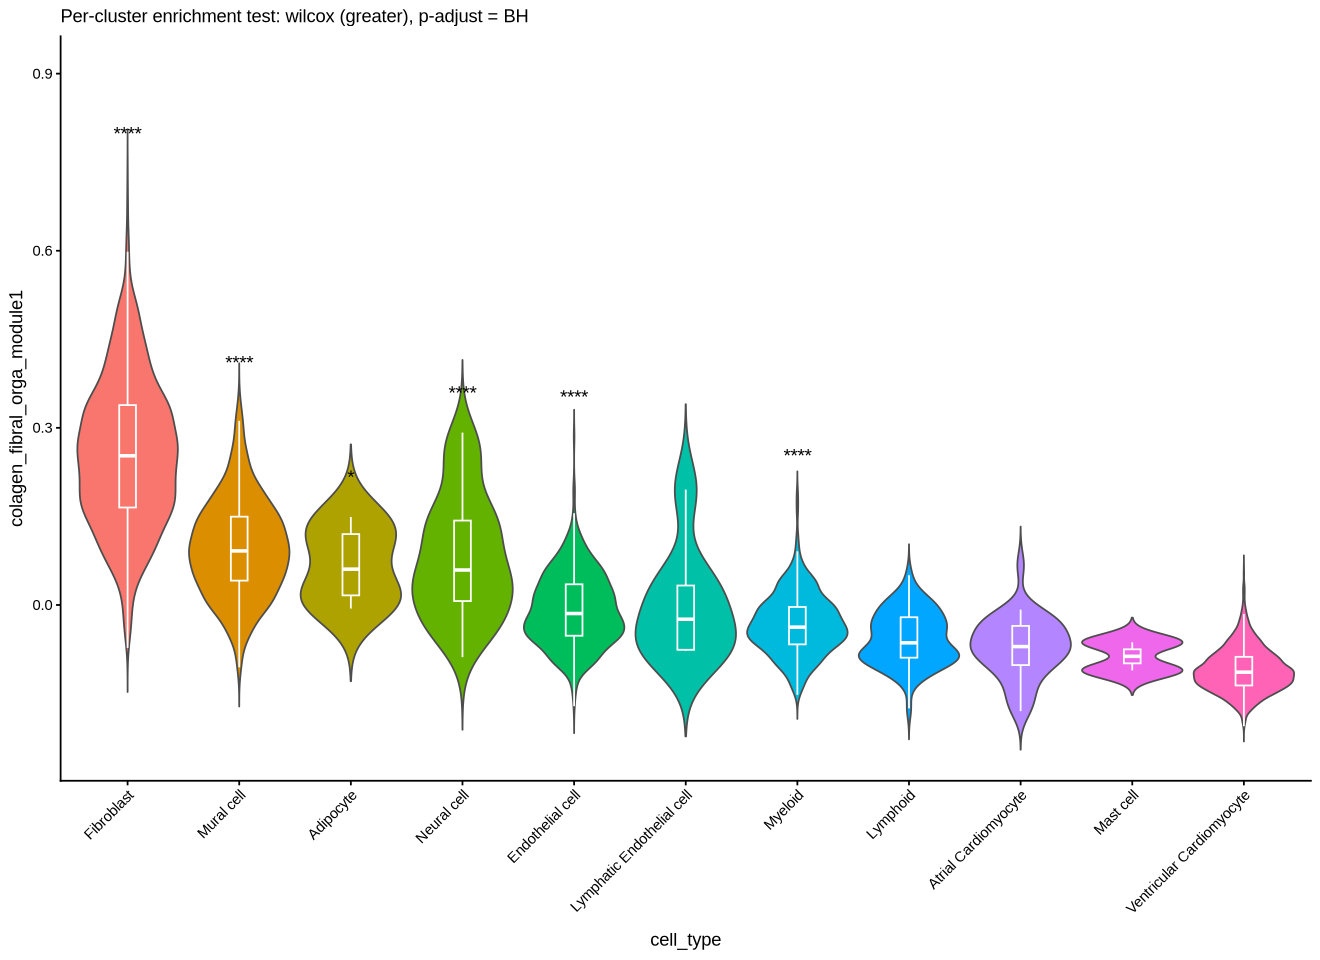

In [ ]:
res <- plot_module_scores(
  object = global_analysis_out,
  seed_genes = colagen_fibral_orga$SYMBOL,
  module_name = "colagen_fibral_orga_module",
  assay_name = "RNA",
  cluster_name = "cell_type",
  test_method = "wilcox",     # or "t.test"
  alternative = "greater",    # enrichment = higher in cluster than others
  label_type = "stars",
  show_ns = FALSE
)
res$plot

In [ ]:

ggsave(paste0(outpath,"/peak_plots/module_enrichment.pdf"), plot = res$plot, width = 8, height = 6)

## for whole pathway

In [ ]:
get in python:

import pandas as pd
import requests
from io import StringIO

go_genes = colagen_fibral_orga$SYMBOL

url = "https://omnipathdb.org/interactions/"
params = {
    "genesymbols": 1,
    "datasets": "collectri",
    "organisms": 9606,
    "targets": ",".join(go_genes),
    "fields": "sources,references"
}

r = requests.get(url, params=params, timeout=60)
r.raise_for_status()

raw = pd.read_csv(StringIO(r.text), sep="\t")

priorGRN = (
    raw[["target_genesymbol", "source_genesymbol"]]
    .rename(columns={"target_genesymbol": "gene", "source_genesymbol": "TF"})
    .dropna()
    .drop_duplicates()
    .sort_values(["gene", "TF"])
    .reset_index(drop=True)
)



In [ ]:
seed_genes <- colagen_fibral_orga$SYMBOL


# 1. begin with linking peaks

[1] "list"
[1] "data.frame"
                  EID     TF Prior TS_atrial_appendage TS_left_ventricle
6002  ENSG00000038295 ZBTB33     0                   0                 1
16185 ENSG00000083444   PURA     1                   0                 1
47456 ENSG00000115318   ATF1     1                   1                 0
84556 ENSG00000139329  CTCFL     0                   0                 1
84981 ENSG00000139687  KDM2B     0                   0                 1
89856 ENSG00000143196   E2F6     0                   0                 1
      net_atrial_appendage net_left_ventricle  gene
6002              -0.34048            0.20056  TLL1
16185              4.68150            4.96780 PLOD1
47456              6.16020            5.99380 LOXL3
84556             -0.55520            0.26590   LUM
84981             -0.21528            0.23777   RB1
89856             -0.47164            0.12442   DPT
[1] "Linking peaks to genes..."
 [1] "TLL1"     "PLOD1"    "LOXL3"    "LUM"      "RB1"      "DPT"

Found gene coordinates for 63 genes

Testing 64 genes and 4339 peaks



[1] "Computing peak-gene distances..."
[1] "Filtering links for promoters..."
  [1]  TRUE FALSE  TRUE  TRUE  TRUE FALSE FALSE FALSE FALSE  TRUE  TRUE  TRUE
 [13]  TRUE  TRUE  TRUE  TRUE  TRUE FALSE FALSE FALSE FALSE  TRUE  TRUE  TRUE
 [25]  TRUE  TRUE  TRUE  TRUE  TRUE FALSE FALSE FALSE  TRUE FALSE  TRUE  TRUE
 [37]  TRUE  TRUE FALSE FALSE FALSE  TRUE FALSE  TRUE FALSE  TRUE  TRUE  TRUE
 [49]  TRUE  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [61] FALSE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE FALSE FALSE  TRUE  TRUE  TRUE
 [73] FALSE FALSE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE FALSE FALSE
 [85] FALSE FALSE FALSE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE FALSE FALSE FALSE
 [97] FALSE FALSE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
[109]  TRUE FALSE FALSE FALSE FALSE FALSE FALSE  TRUE  TRUE  TRUE FALSE FALSE
[121] FALSE FALSE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE  TRUE  TRUE  TRUE
[133]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRU

Computing hash



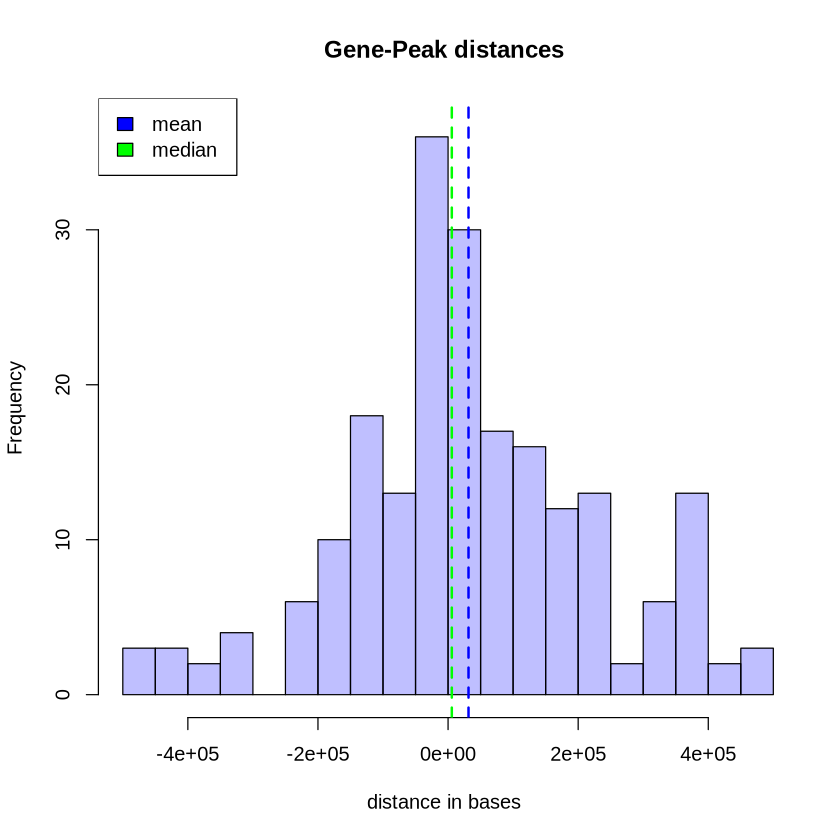

In [ ]:
res_links <- linking_peaks_for_module_cluster(global_analysis_out, 
                                seed_genes, 
                                priorGRN, 
                                cluster=cluster,
                                gene_name_2_gene_id)

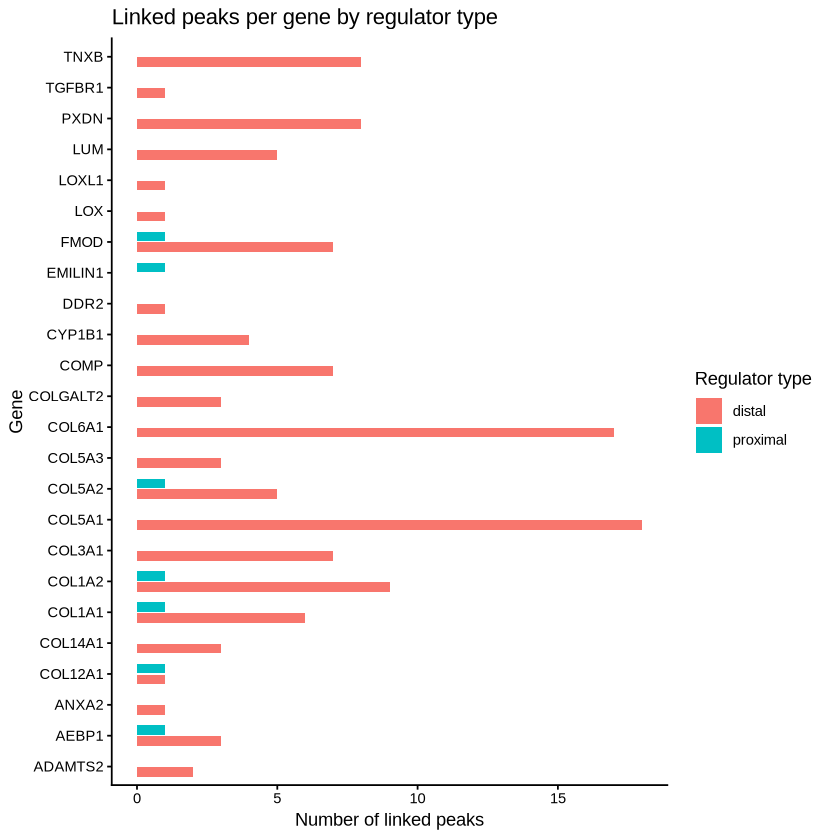

In [34]:
res_links$plot_links

In [ ]:
p <- plot_links_per_gene(res_links$plot_links)
ggsave(paste0(outpath,"/peak_plots/links_distr.png"), plot = p, width = 6, height = 6)


# 2. identify cluster specific peaks

In [ ]:
#understand what peak stants does 
# adds object@misc$peak_stats
# adds filtered version: object@misc$df.stats.filtered

In [31]:
seeds_for_peaks_stats <- data.frame(
  cluster = "Fibroblast",
  gene = res_links$seeds[["gene"]],
  annotation = "colagen_fibral_orga",
  stringsAsFactors = FALSE
)


In [33]:

# seeds here needs: gene, cluster, annotation
res_peak_stats <-do_peak_stats(object=res_links$object, seeds=seeds_for_peaks_stats, promoter.needed = FALSE)

[1] "Writing peak stats table..."
[1] "Conducting cluster specific statistical tests..."
[1] "Calculating zero expression stats..."
[1] "Clustering peaks for bg distributions..."


Warning message:
"Quick-TRANSfer stage steps exceeded maximum (= 6337300)"


[1] "Counting peaks per seed..."
[1] "Filtering peak stats..."
[1] "Number of linked peaks after filtering: 122"

            both cluster_specific           global 
              90                8               24 


# 3. do local motif stats

- adds to:
    - object@misc$motifs.inProximalPeaks
    - object@misc$motifs.inDistalPeaks

In [40]:
res_local_motif_stats <- do_local_motif_stats(object=res_peak_stats, 
                               seeds=seeds_for_peaks_stats,
                               fragpath=NULL,
                               peaks_assay='peaks',
                               background_size=50, parallel=TRUE,
                               min_count=1, min_log2FC=1, max_t_stat=0, min_p_adjust=0.05)

Calculating motif enrichment

counting motifs in linked peaks

n gene/cluster pairs: 23

Preparing motif overlap cache sequentially ...

n gene/cluster pairs: 23

[cache] 1/23 : ADAMTS2 | Fibroblast

[cache] 23/23 : TNXB | Fibroblast

precomputing motif GRanges cache

running per-gene motif enrichment in parallel with 20 worker(s)

counting motifs in promoter region

Filtering motif enrichment

Adding footprint stats

Warning message:
"The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead."
Warning message in filtered.enrichment$footprint.p_value_adj[filtered.enrichment$gene == :
"number of items to replace is not a multiple of replacement length"


# 4. Map motifs to TFs

In [44]:
res_motifs_mapped<-add_motif_TF_mapping(res_local_motif_stats)

# 5. draw network

In [45]:
colnames(priorGRN)[colnames(priorGRN) == "gene_name"] <- "gene"
priorGRN

,Gene,TF,Prior,TS_atrial_appendage,TS_left_ventricle,net_atrial_appendage,net_left_ventricle,gene
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>
6002,ENSG00000038295,ZBTB33,0,0,1,-0.340480,0.200560,TLL1
16185,ENSG00000083444,PURA,1,0,1,4.681500,4.967800,PLOD1
47456,ENSG00000115318,ATF1,1,1,0,6.160200,5.993800,LOXL3
84556,ENSG00000139329,CTCFL,0,0,1,-0.555200,0.265900,LUM
84981,ENSG00000139687,KDM2B,0,0,1,-0.215280,0.237770,RB1
89856,ENSG00000143196,E2F6,0,0,1,-0.471640,0.124420,DPT
89857,ENSG00000143196,EGR3,0,0,1,-0.260850,0.412610,DPT
89858,ENSG00000143196,INSM1,0,0,1,-0.041592,0.790960,DPT
89859,ENSG00000143196,CTCFL,0,0,1,-0.349960,0.460940,DPT


[1] "include_motifs_for_seed: TLL1 Fibroblast"
[1] "motif stats for seed:TLL1Fibroblast"
NULL
[1] "motif stats for seed:TLL1Fibroblast"
NULL


found and passed 0 Transcription factors that bind in regulatory regions for seed TLL1 Fibroblast



NULL
[1] 0
character(0)


No TFs found for seed, as no peak is linked to seed



[1] "include_motifs_for_seed: PLOD1 Fibroblast"
[1] "motif stats for seed:PLOD1Fibroblast"
NULL
[1] "motif stats for seed:PLOD1Fibroblast"
NULL


...

  [1] gray   red    blue   red    red    yellow red    red    red    green 
 [11] red    red    red    red    red    yellow yellow red    yellow yellow
 [21] red    red    red    yellow red    yellow yellow red    yellow green 
 [31] green  yellow green  yellow red    yellow red    yellow yellow yellow
 [41] red    yellow yellow yellow yellow red    yellow green  yellow green 
 [51] red    red    red    yellow yellow yellow yellow green  red    yellow
 [61] red    red    yellow yellow yellow red    red    red    red    red   
 [71] yellow red    yellow red    red    yellow red    red    red    red   
 [81] red    yellow red    red    red    red    red    yellow yellow red   
 [91] red    red    yellow green  red    yellow yellow red    yellow yellow
[101] red    red    yellow red    yellow green  yellow yellow green  yellow
[111] yellow green  red    red    yellow yellow green  yellow yellow red   
[121] green  red    yellow yellow
Levels: green yellow red blue black gray


colors are numbers at the end: is this going wrong here already?



 [1] blue   gray   red    red    red    yellow yellow red    red    red   
[11] yellow yellow yellow yellow red    red    red    red    red    red   
[21] red    yellow yellow yellow yellow yellow yellow red    yellow green 
[31] red    red    red    red    red    red    red    red    yellow red   
[41] yellow yellow yellow green  green  yellow yellow yellow yellow yellow
[51] yellow yellow yellow
Levels: green yellow red blue black gray


edge_color at the end of get_subnetwork



 [1] blue   gray   red    red    red    yellow yellow red    red    red   
[11] yellow yellow yellow yellow red    red    red    red    red    red   
[21] red    yellow yellow yellow yellow yellow yellow red    yellow green 
[31] red    red    red    red    red    red    red    red    yellow red   
[41] yellow yellow yellow green  green  yellow yellow yellow yellow yellow
[51] yellow yellow yellow
Levels: green yellow red blue black gray
                  from       to  color priorTF reg_type in.prom
LUM.1             NFYA      LUM   blue    TRUE        2       3
LUM.2            PPARG      LUM   blue    TRUE        2       1
LUM.3            FOXG1      LUM    red   FALSE        2       3
LUM.4            TBX20      LUM yellow   FALSE        2       1
LUM.5            VENTX      LUM yellow   FALSE        2       3
LUM.6             RARA      LUM    red   FALSE        2       1
LUM.7             TBX4      LUM yellow   FALSE        2       1
LUM.8             TBX5      LUM yellow   FALSE

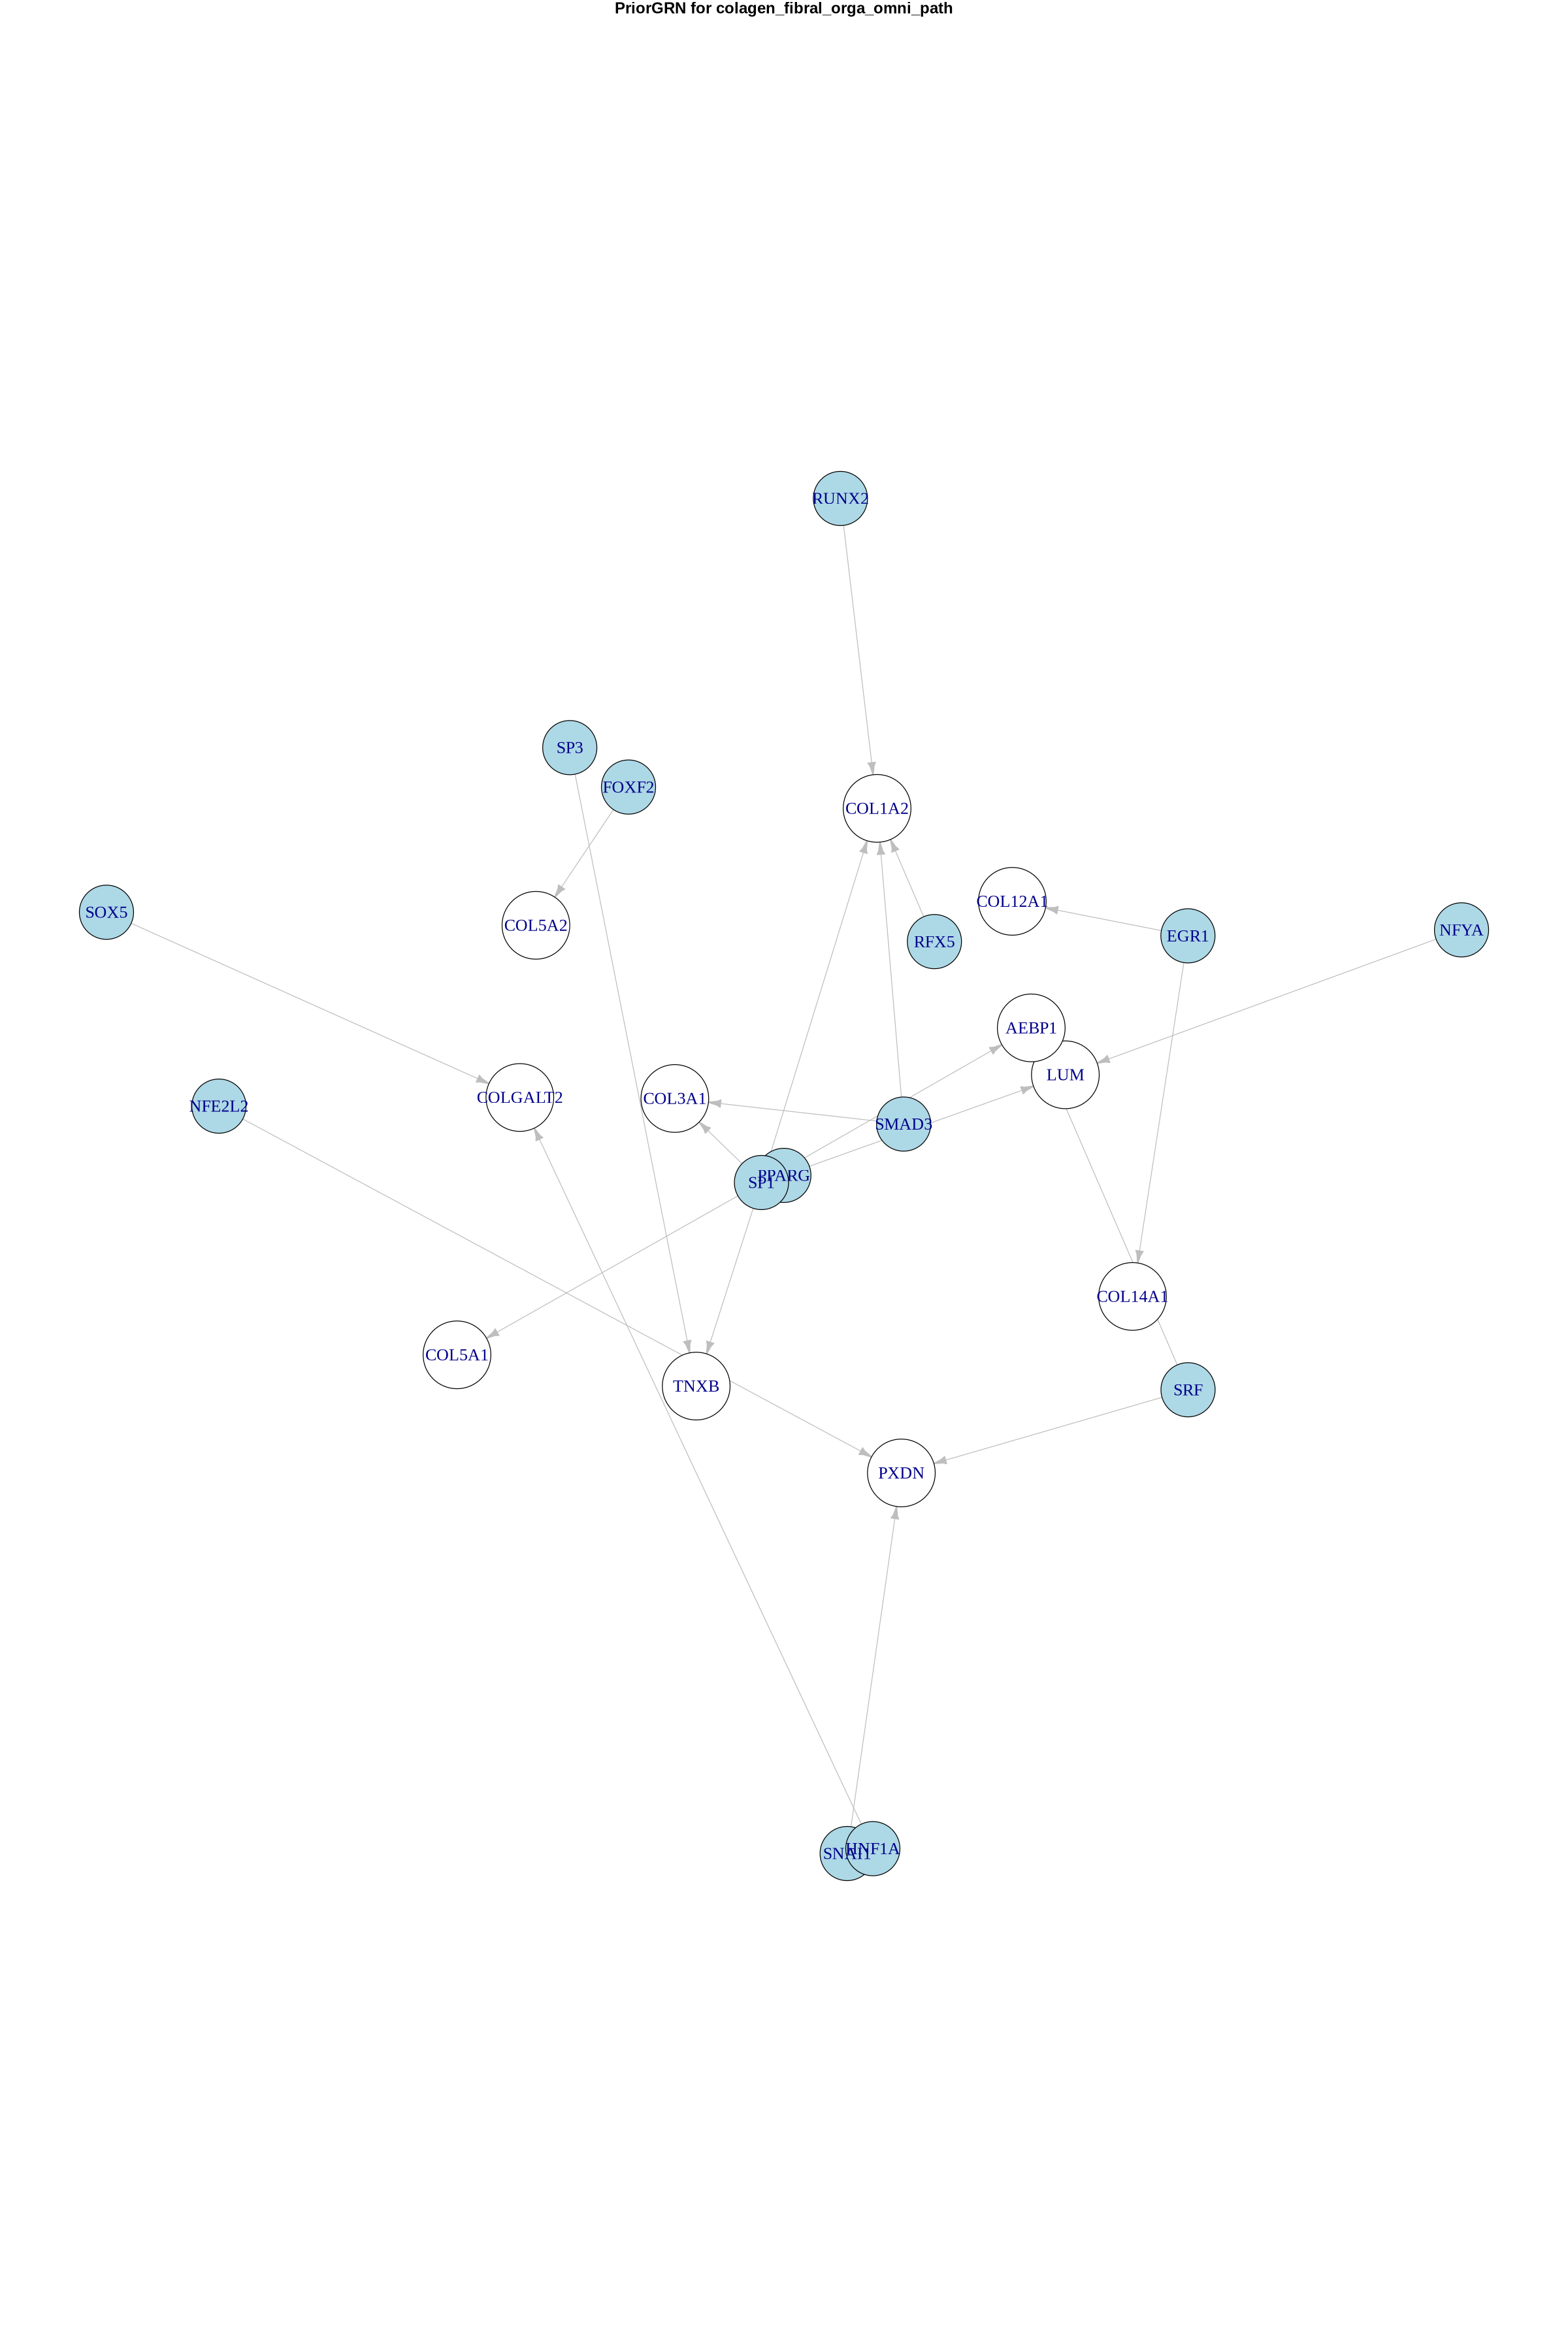

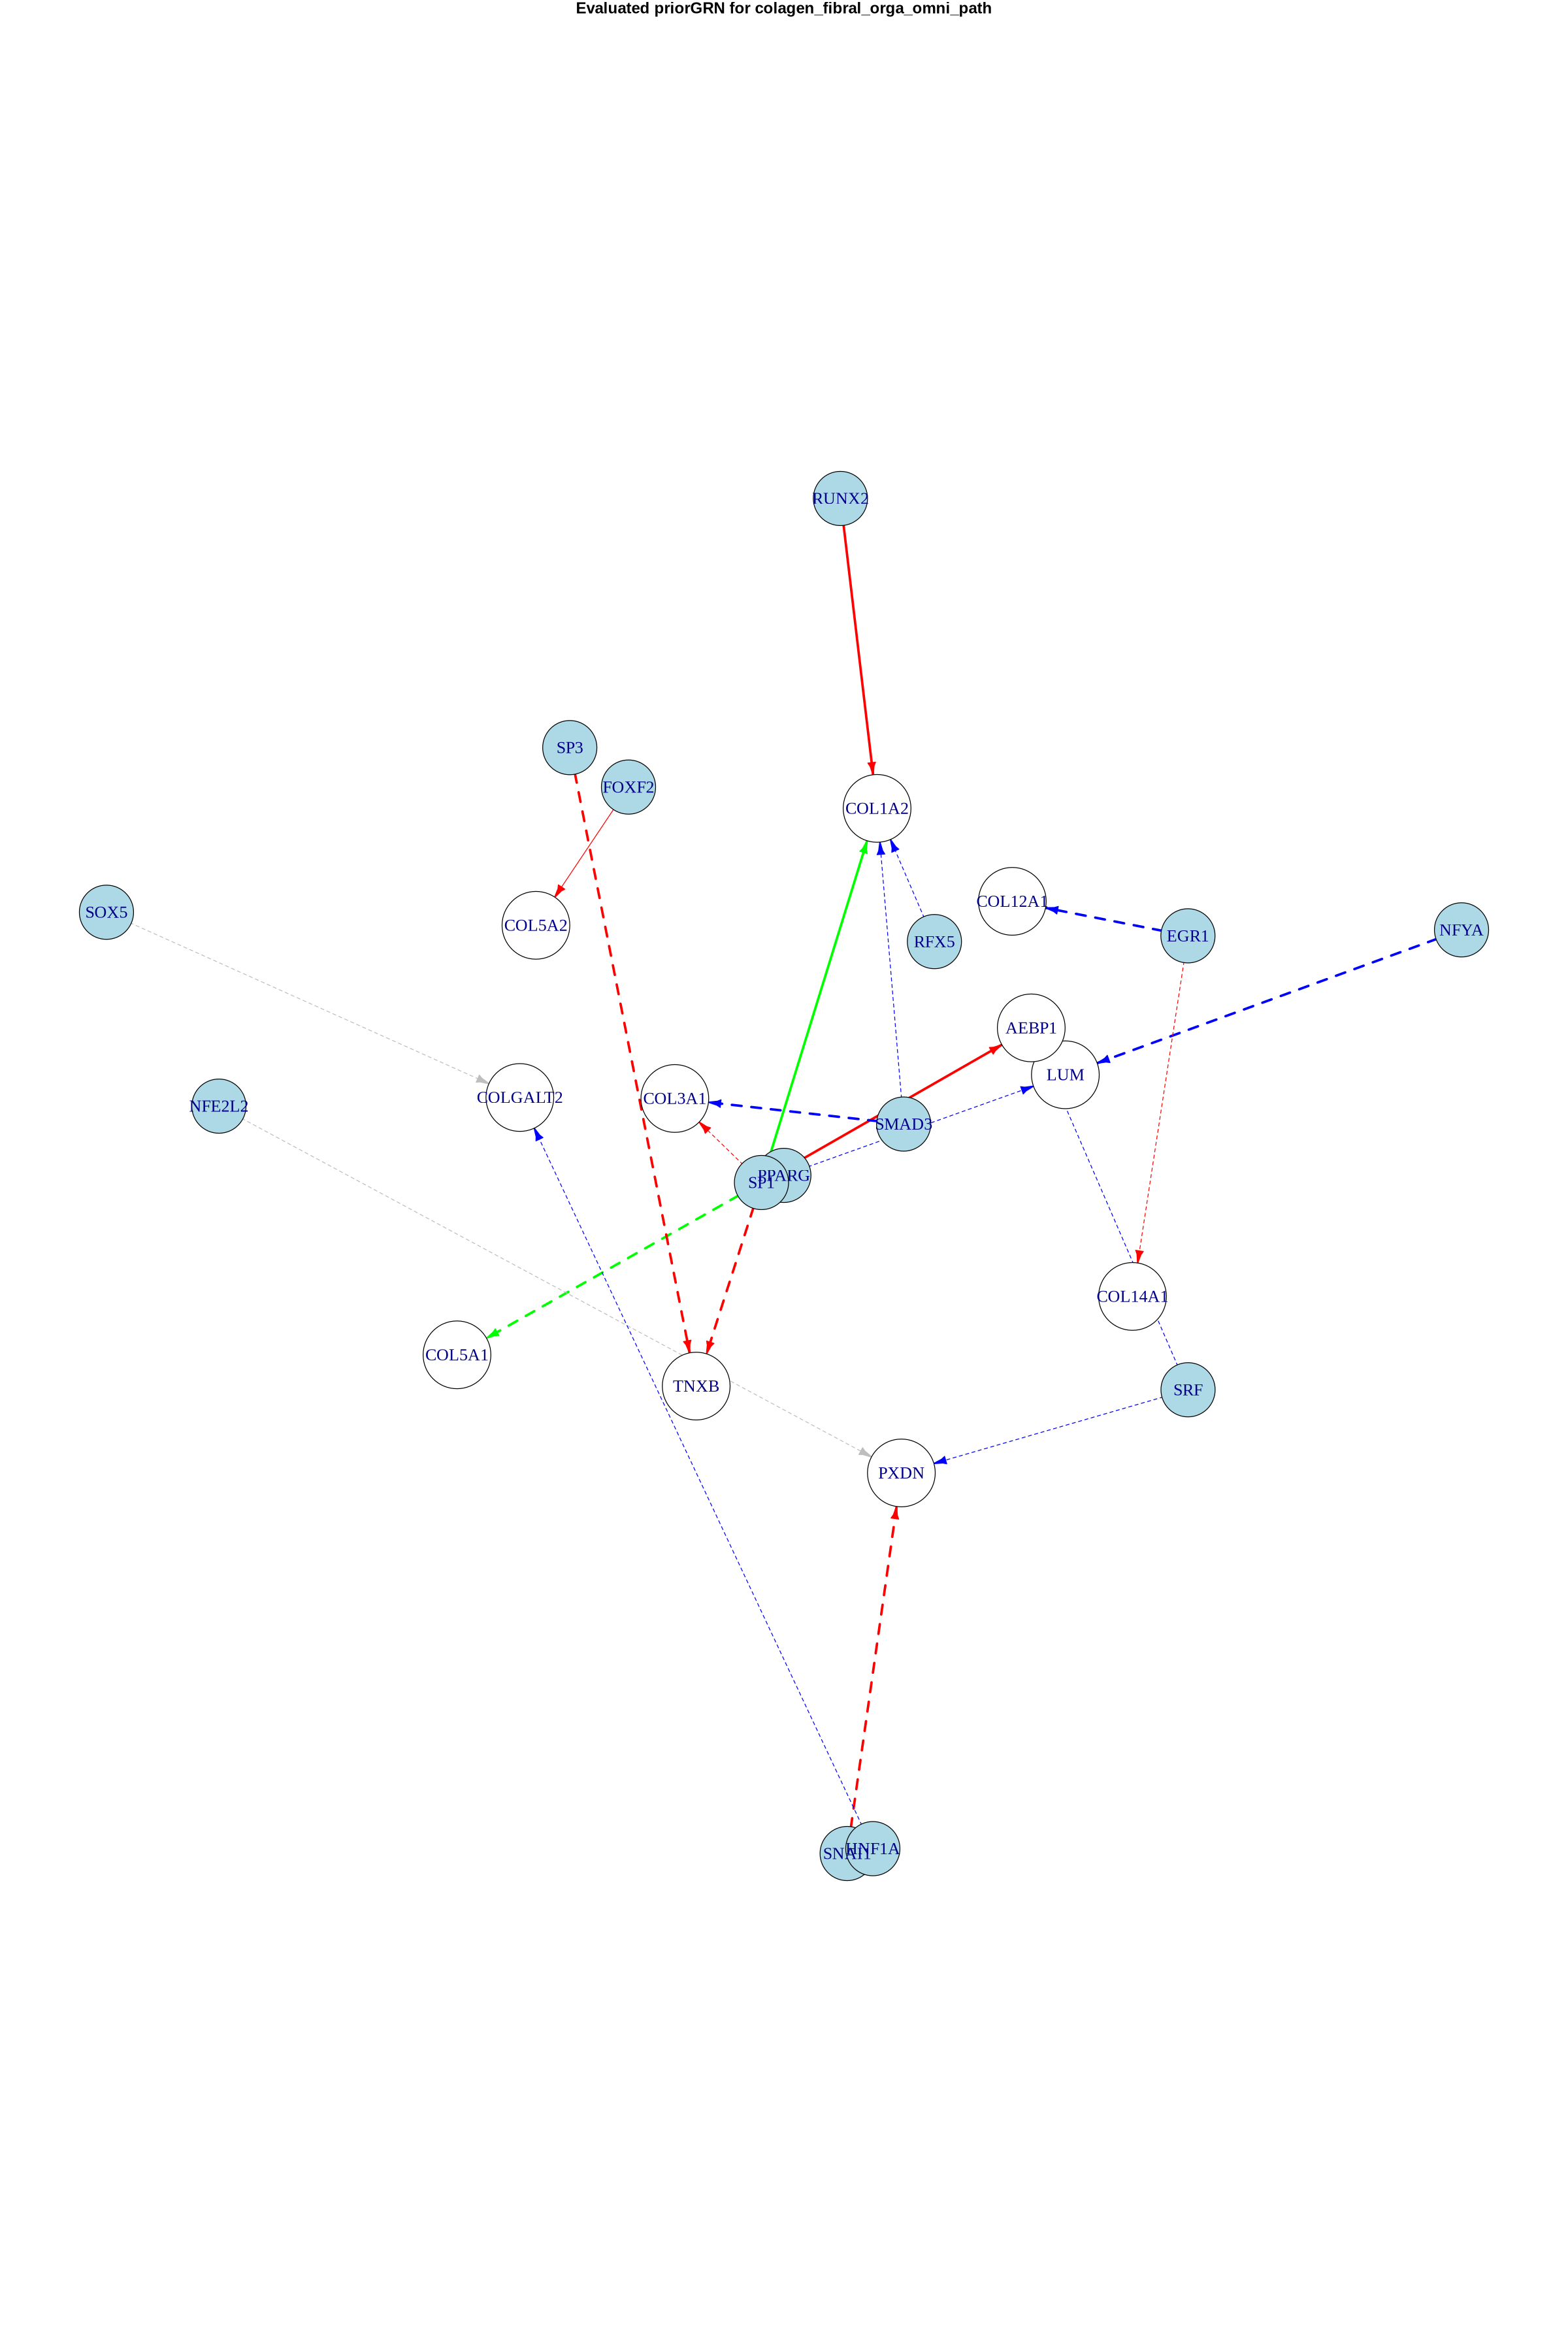

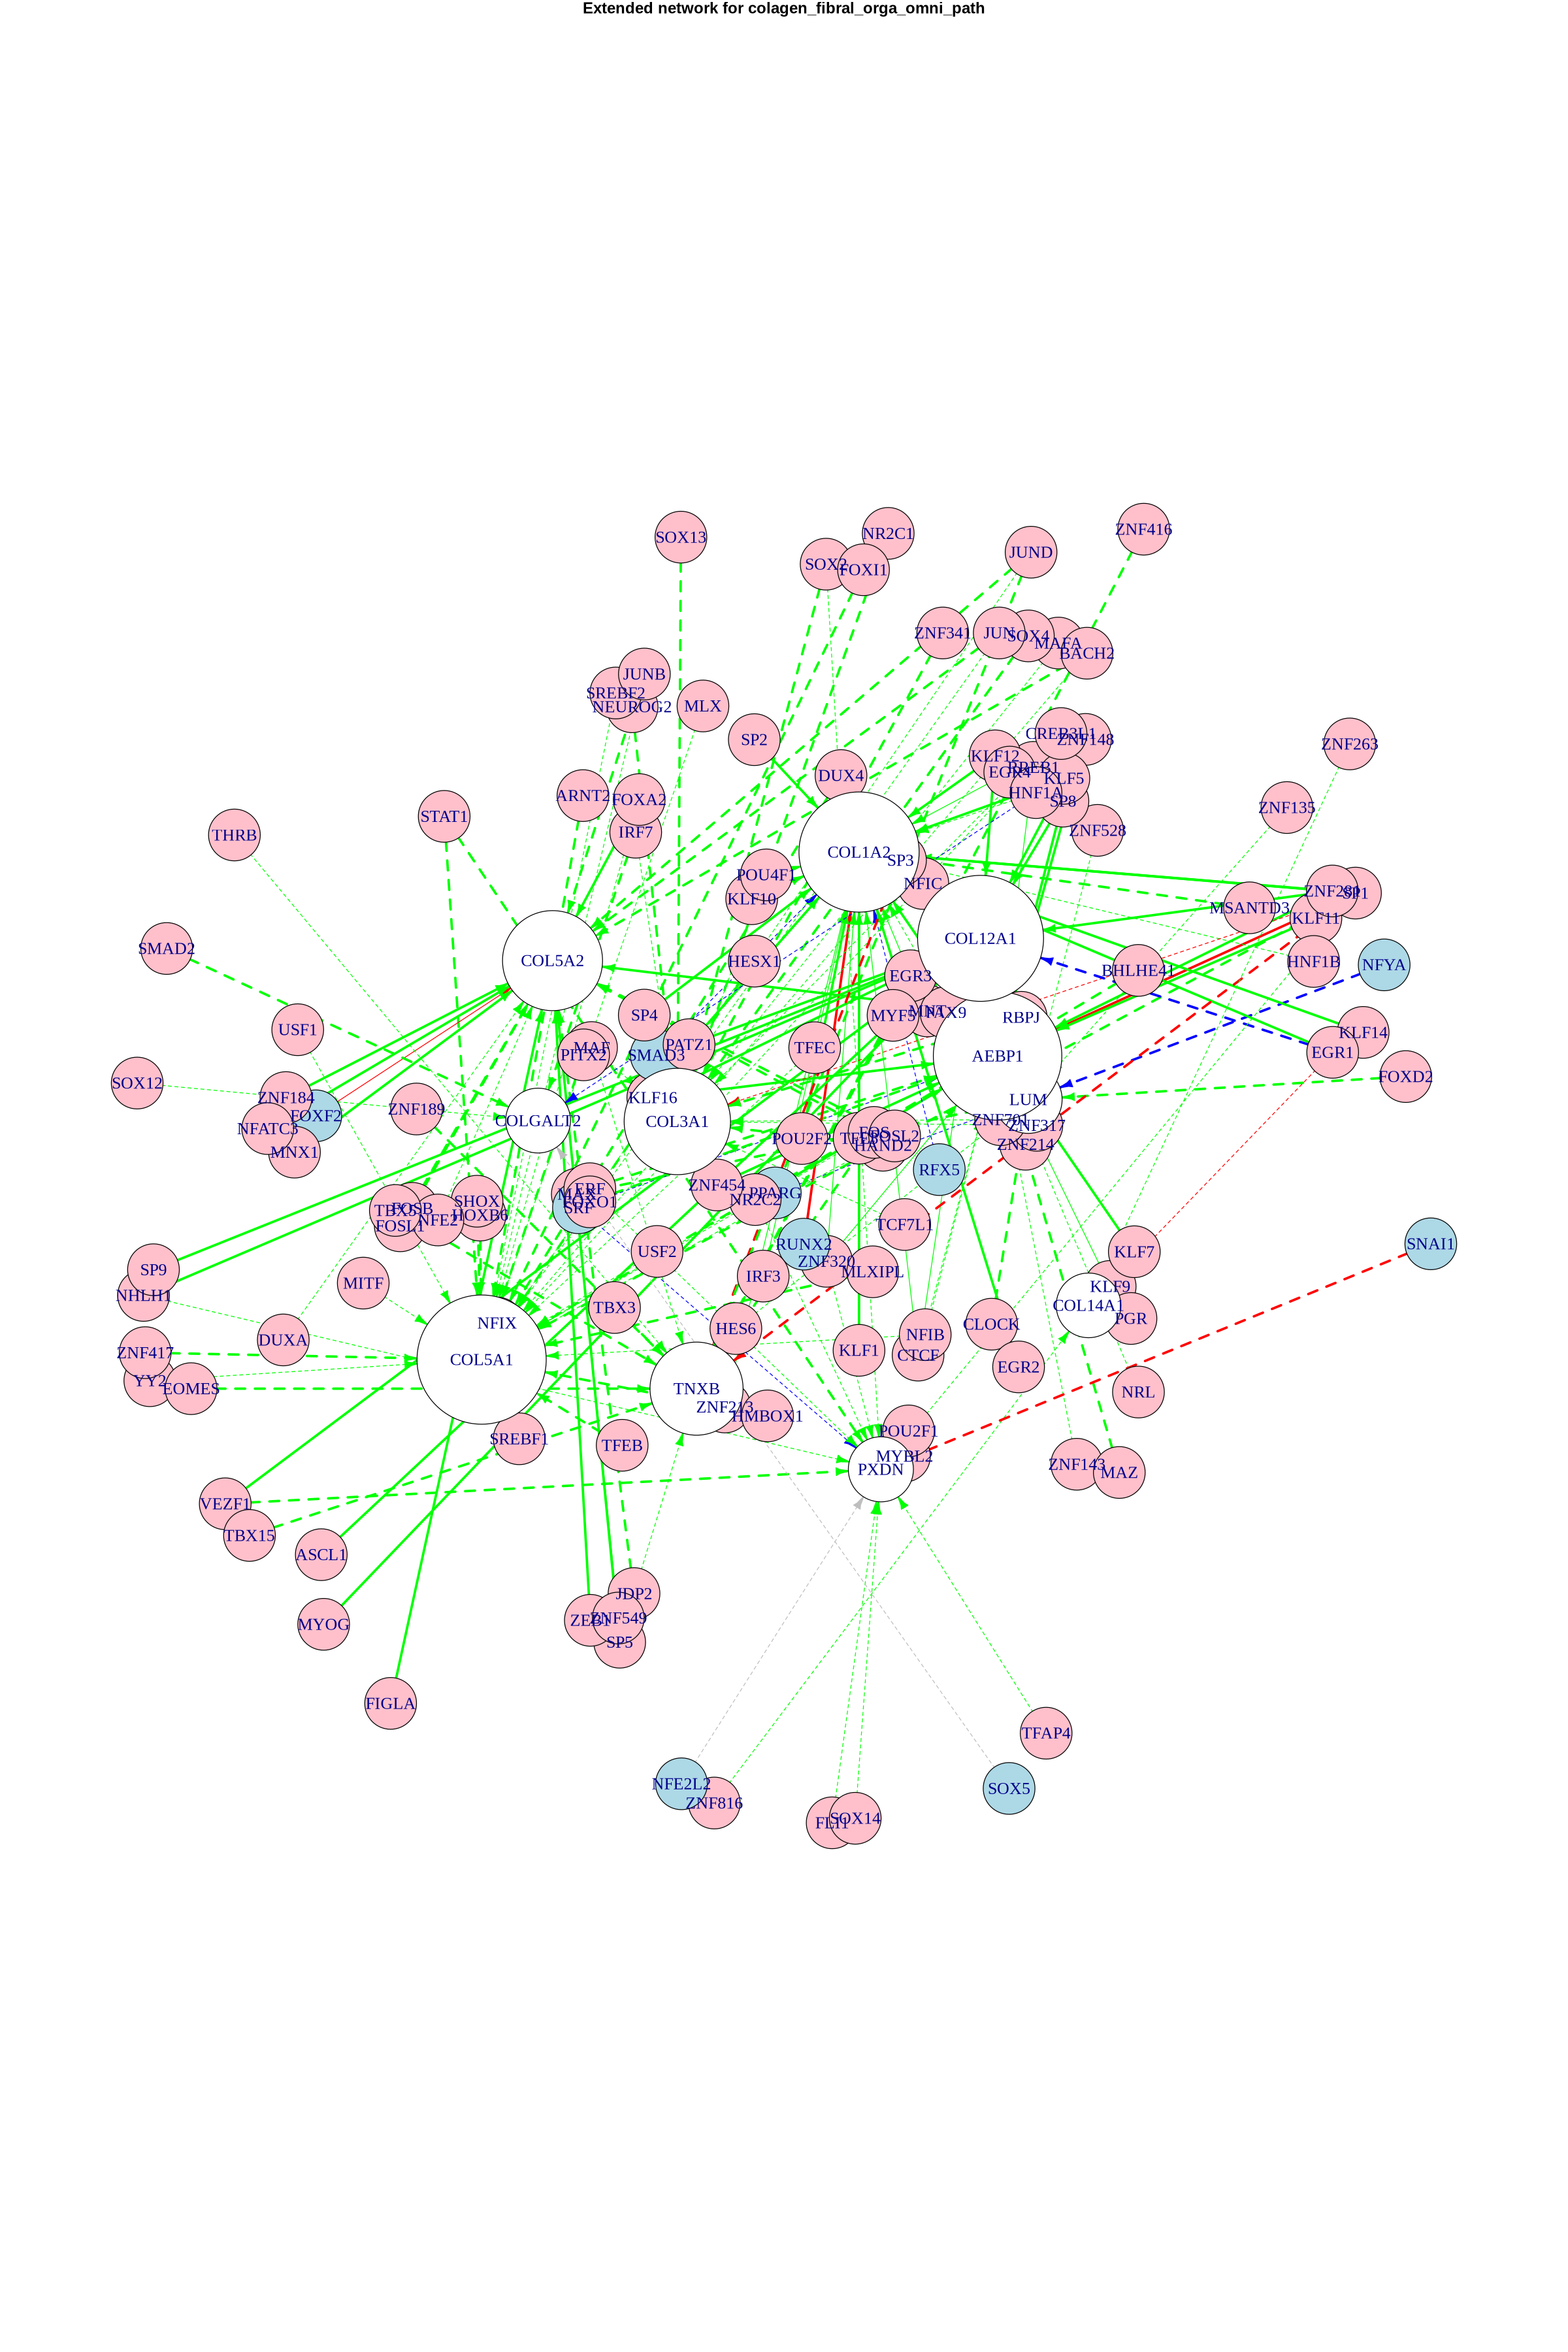

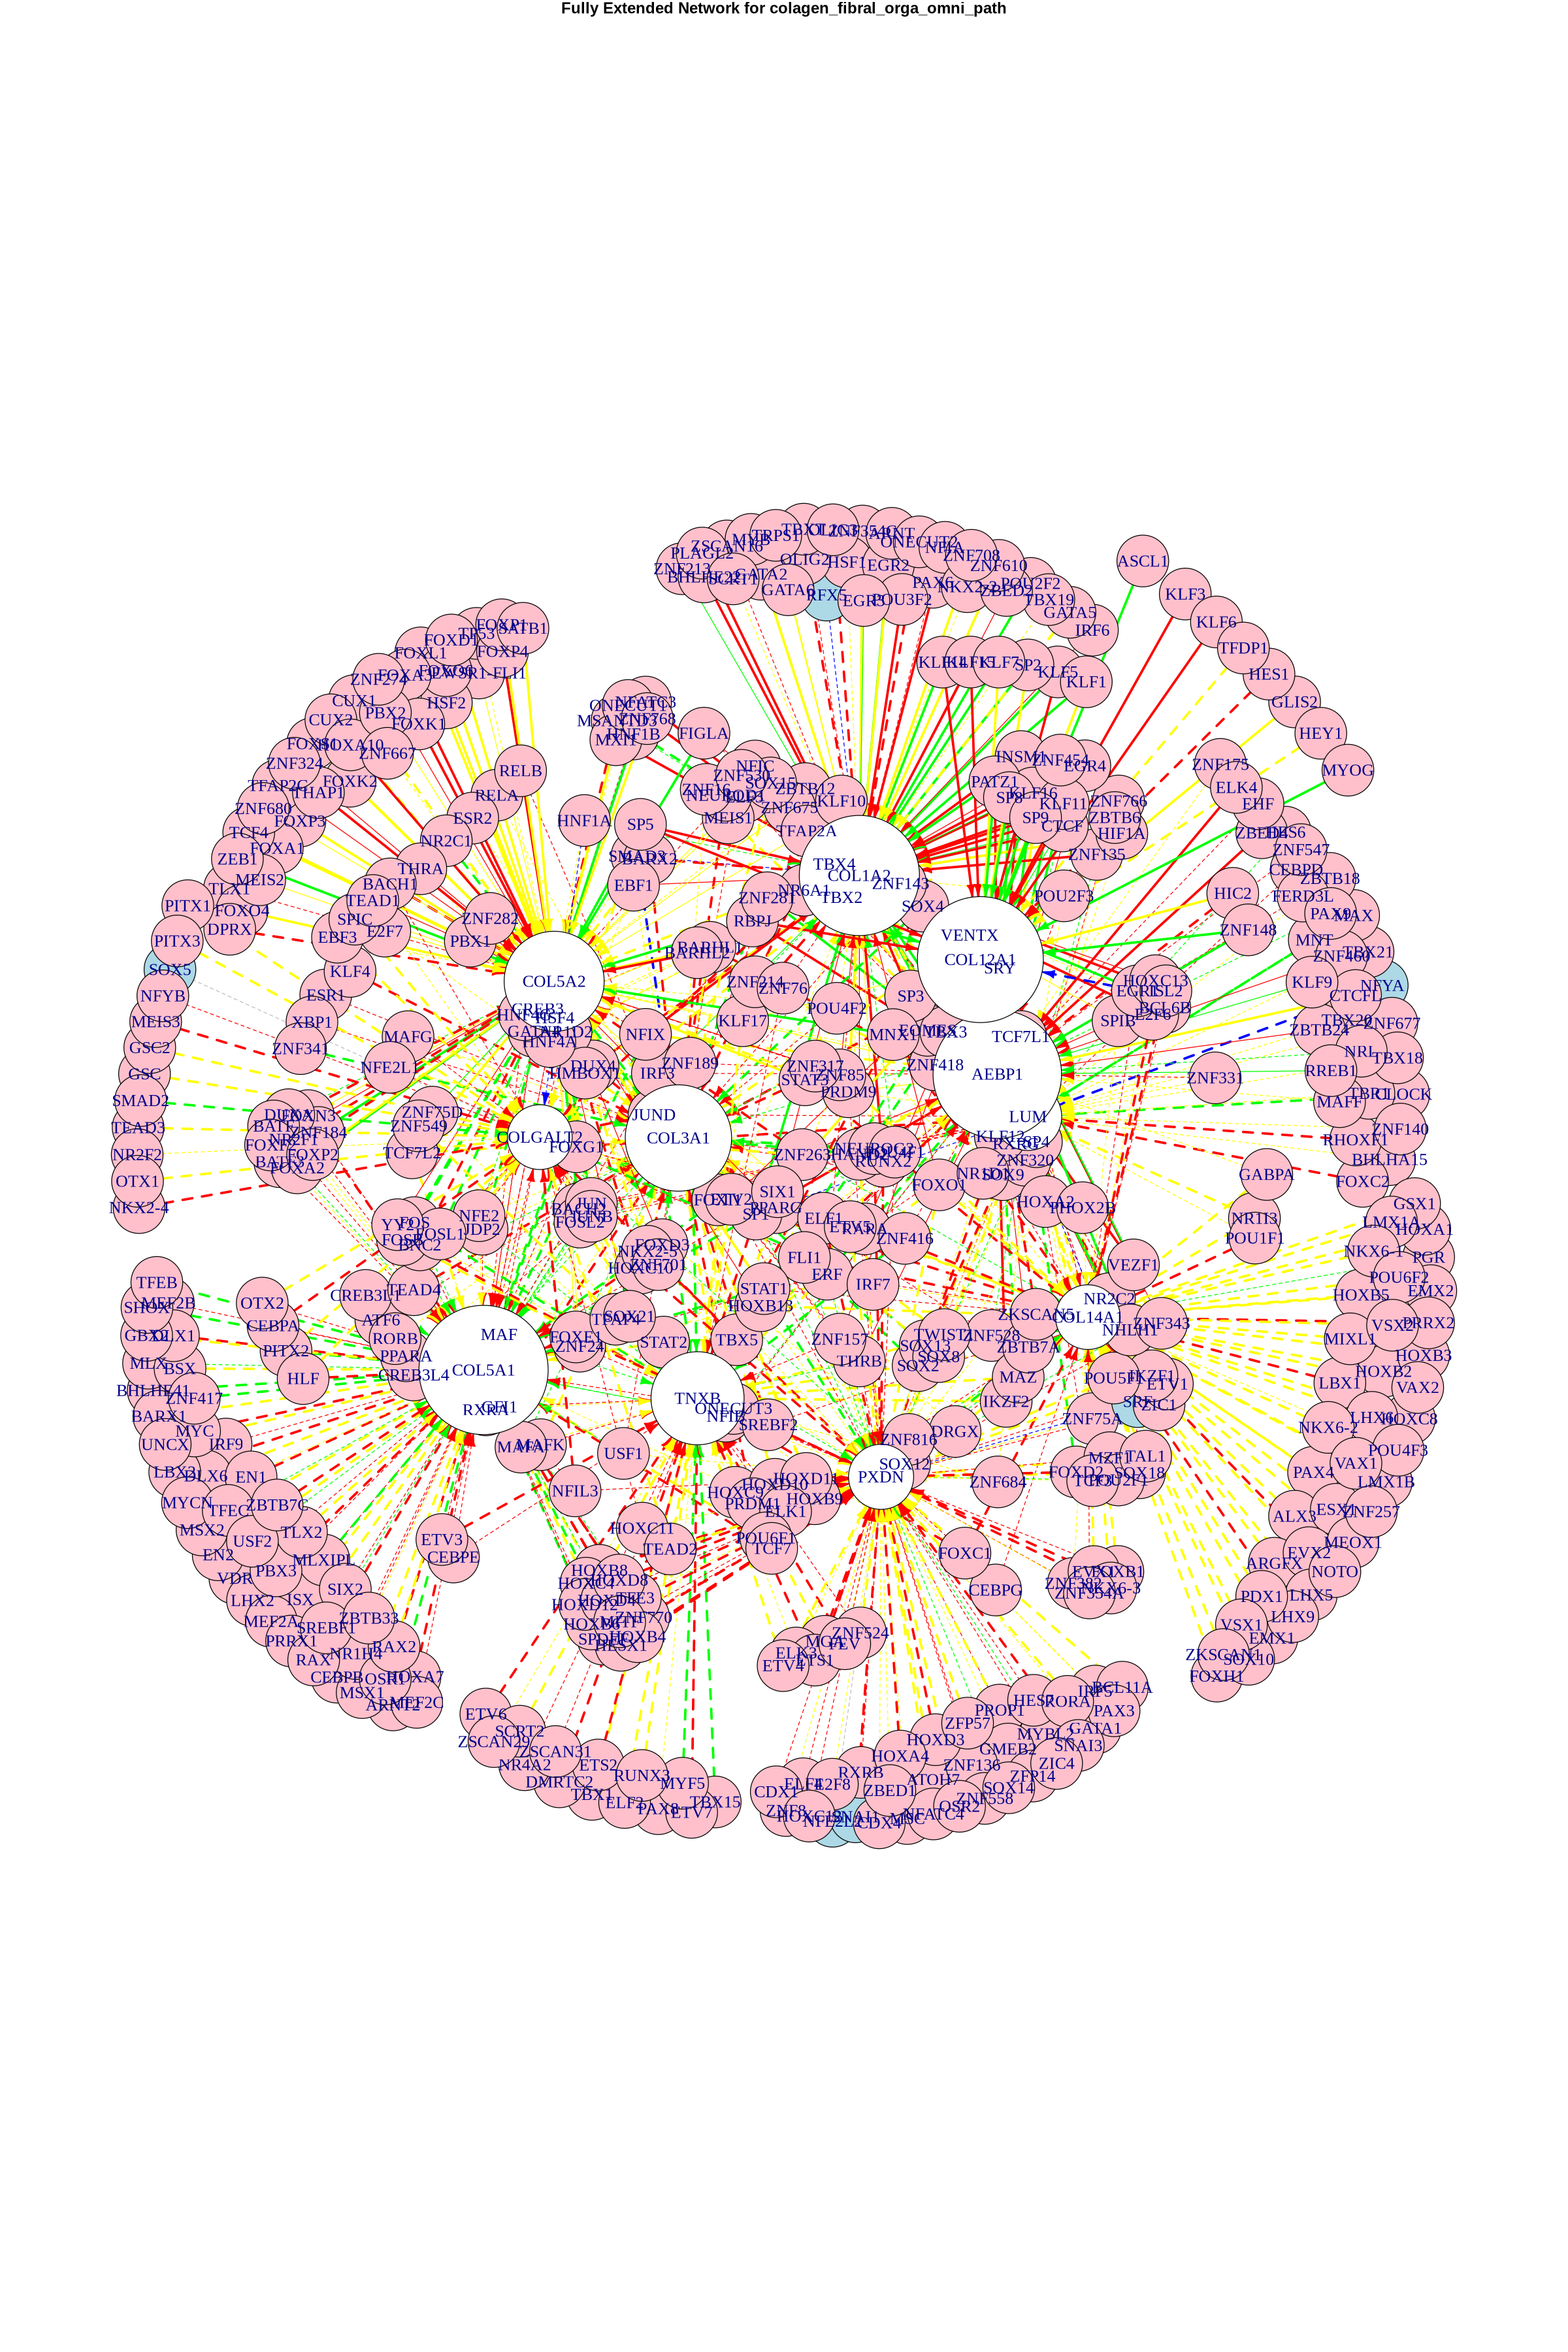

In [ ]:

object_w_net<-draw_subNetwork_for_context(object=res_motifs_mapped, 
        gene_list= seed_genes,
        cluster.specific=TRUE,
        priorGRN=priorGRN,
        cluster=cluster,
        context_name='analysis_name',resolution=20,pointsize=50, sd=5, score=-0.5
        )

# save files

In [ ]:
saveRDS(paste0(outpath,"/GRN_object.rds"), object_w_net)

## explainations peak-stats 
#### Identity columns 
- 'cluster'
- 'peak'
- 'gene'
- 'annotation': seed gene, or module gene (from prior net), or marker gene
- 'regulatorType': proximal: 100-2000 upstream TSS, else distal

#### LinkPeaks stats: across all clusters
- 'signac.scores': The raw Signac link score from Links(object)$score
- 'signac.zscores': The Signac link z-score from Links(object)$zscore
- 'signac.pvalues': The Signac link p-value from Links(object)$pvalue

#### Cluster-specific peak accessibility test columns: conduct_stat_test() using test='t-test', test_activation=TRUE (is this peak more accessible in the target cluster than outside it?)
foreground: cells of cluster,  background: all other cells, alternative: greater
- t-stat_highly.acc: The one-sided t-test statistic for target-cluster accessibility > background accessibility
- p.value-t.test_highly.acc: The raw p-value from that one-sided t-test
- p.value-t.test_highly.acc_Bonf: Bonferroni-adjusted p-value across all unique (cluster, peak) tests
- p.value-t.test_highly.acc_BH: Benjamini–Hochberg adjusted p-value across all unique (cluster, peak) tests

#### Probability / zero-expression columns: zero_expression_stats() and calc_prob_stats(gene_expr, peak_acc)
(n_cells = number of cells in cluster
n_expr = # cells with gene_expr != 0
n_acc = # cells with peak_acc != 0
n_joint = # cells with gene_expr != 0 AND peak_acc != 0)

- expr_not_0 = n_expr / n_cells: Fraction of cells in the target cluster where the gene is expressed
- acc_not_0 = n_acc / n_cells: Fraction of cells in the target cluster where this peak is accessible
- expr_not_0.given_acc = n_joint / n_acc: Conditional probability that the gene is expressed among cells where this peak is accessible, within the target cluster: P(expr != 0 | acc != 0) in the cluster
- expr_and_acc_not_0 = n_joint / n_cells: Joint fraction of target-cluster cells with both gene expression and peak accessibility nonzero: P(expr != 0 AND acc != 0) in the cluster.
- FC.expr_given_acc = expr_not_0.given_acc / expr_not_0: Fold-enrichment of gene expression among accessible cells relative to the cluster baseline expression rate: So values above 1 mean expression is enriched among cells where the peak is open

#### .bg: Background: same peak, other clusters: 
These are computed on the same peak and same gene, but using all cells outside the target cluster.
.all: same peak, All cells:
These are the same metrics as above but computed using all cells for the same gene and same peak.

#### Per-seed peak counts
- 'promotersLinkedToSeed': Number of linked peaks for this (gene, cluster) whose regulatorType == "proximal"
- 'distalPeaksLinkedToSeed': Number of linked peaks for this (gene, cluster) whose regulatorType == "distal"

#### Convenience / derived filter columns
- 'acc_cells_cluster': Estimated number of accessible cells in the target cluster for this peak: acc_cells_cluster = acc_not_0 * cluster_size where cluster_size = table(Idents(object))[cluster]
- 'delta_expr_given_acc.same_peak_bg': Difference in conditional expression between target cluster and background, for the same peak: expr_not_0.given_acc - expr_not_0.given_acc.bg
(- 'delta_expr_given_acc.other_peaks.same_cluster': Difference between the target peak and the “other linked peaks of same gene” summary, inside the target cluster:
expr_not_0.given_acc - expr_not_0.given_acc.bg_other_peaks.same_cluster
'delta_expr_given_acc.other_peaks.all': Difference between the target peak’s across-all-cells conditional expression and the “other linked peaks of same gene” across-all-cells summary: expr_not_0.given_acc.all - expr_not_0.given_acc.bg_other_peaks.all)

#### Final filter flags
- 'pass_cluster_specific'
    - promoter requirement, if enabled: promotersLinkedToSeed > 0
    - p.value-t.test_highly.acc_BH < th
    - t-stat_highly.acc > cluster_t_min
    - acc_cells_cluster >= min.cells
    - expr_and_acc_not_0 >= cluster_expr_given_acc_min
    - expr_not_0.given_acc > expr_given_acc_th
    - FC.expr_given_acc > cluster_fc_min
    - delta_expr_given_acc.same_peak_bg >= cluster_delta_same_peak_bg_min
- 'pass_global'
    - promoter requirement, if enabled
    - signac.zscores >= global_signac_z_min
    - signac.pvalues < global_signac_p_cutoff
    - expr_and_acc_not_0.all >= global_expr_given_acc_min
    - expr_not_0.given_acc.all > expr_given_acc_th
    - FC.expr_given_acc.all > global_fc_min
- 'pass_any': TRUE if pass_cluster_specific | pass_global
- 'pass_type'

In [ ]:
summary_col_labels_short <- c(
  gene = "Gene",
  cluster = "Cluster",
  annotation = "Annotation",
  peak = "Peak",
  regulatorType = "Class",
  signac.scores = "Link Score",
  signac.zscores = "Link Z",
  signac.pvalues = "Link P",
  `t-stat_highly.acc` = "Acc. T-stat",
  `p.value-t.test_highly.acc_BH` = "Acc. FDR",
  acc_cells_cluster = "Accessible Cells",
  `expr_not_0.given_acc` = "P(expr|acc), cluster",
  `expr_not_0.given_acc.bg` = "P(expr|acc), bg",
  expr_and_acc_not_0 = "P(expr & acc), cluster",
  expr_and_acc_not_0.all = "P(expr & acc), all",
  FC.expr_given_acc = "Enrichment, cluster",
  FC.expr_given_acc.all = "Enrichment, all",
  delta_expr_given_acc.same_peak_bg = "Delta P(expr|acc)",
  promotersLinkedToSeed = "Promoter Peaks",
  distalPeaksLinkedToSeed = "Distal Peaks",
  pass_type = "Pass Type"
)



In [ ]:
# keep only the selected columns, in this order
summary_cols <- c(
  "gene",
  "cluster",
  "annotation",
  "peak",
  "regulatorType",
  "signac.scores",
  "signac.zscores",
  "signac.pvalues",
  "t-stat_highly.acc",
  "p.value-t.test_highly.acc_BH",
  "acc_cells_cluster",
  "expr_not_0.given_acc",
  "expr_not_0.given_acc.bg",
  "expr_and_acc_not_0",
  "expr_and_acc_not_0.all",
  "FC.expr_given_acc",
  "FC.expr_given_acc.all",
  "delta_expr_given_acc.same_peak_bg",
  "promotersLinkedToSeed",
  "distalPeaksLinkedToSeed",
  "pass_type"
)


# filter + rename
peak_stats_summary <- object_w_net@misc$peak_stats[, summary_cols]
colnames(peak_stats_summary) <- summary_col_labels_short[summary_cols]
write.csv(peak_stats_summary, paste0(outpath,"/peak_stats.csv"), row.names = FALSE)


## motif stats: Motif enrichment and footprint scoring
#### Identity Columns
- cluster
- gene
- motif
- TF: Transcription factor that binds motif (if multiple, new row for each)

#### Motif enrichment in linked peaks: motif_enrichment_per_gene() / calculate_enrichments()
logic: 
1. find peaks linked to the gene in the chosen cluster
2. split them into proximal vs distal using regulatorType
3. count how often each motif occurs in those linked peaks
4. compare that to a random background made by replacing each linked peak with a sampled “comparable”(GC content and length) peak from the same peak meta-feature cluster. t-test for enrichment
-> for this: make clusters of comparable peaks, store in object$peaks@meta.features$cluster
##### Proximal motif columns
- proximal.motif_count: The number of occurrences of this motif in proximal peaks linked to the gene in this cluster
- proximal.background_count: The mean motif count in matched random background peak sets for the proximal linked peaks. For each background draw, every linked proximal peak is replaced by a sampled peak from the same object$peaks@meta.features$cluster, then motif counts are computed, and the mean over draws is stored here
- log2FC.proximal: log2(proximal.motif_count / proximal.background_count): log2 enrichment of proximal motif count over matched background. Positive values mean enrichment; zero means no enrichment; negative values mean depletion
- t_stat.proximal: The t-statistic from testing the proximal background distribution against the foreground proximal count using
t.test(col_bg, mu = value_fg, alternative = "less") in effect. Interpreted practically, small p-values support that the background mean is lower than the foreground count, i.e. the motif is enriched in the linked proximal peaks.
- p_value.proximal: The raw p-value for that proximal enrichment test.
- p_adjust.proximal: A simple multiplicity-adjusted proximal p-value, computed as raw p_value.proximal * number_of_motifs, then capped at 1. This is Bonferroni-like, not BH/FDR.

##### Distal motif columns: analog to proximal, but using distal peaks
- distal.motif_count
- distal.background_count
- log2FC.distal = log2(distal.motif_count / distal.background_count)
- t_stat.distal
- p_value.distal
- p_adjust.distal

##### Promoter motif column
- promoter.motif_count: The number of occurrences of this motif in the gene’s promoter sequence, regardless of whether there is an accessible linked peak there. This is computed by get_tf_bindingsites_in_region(), which scans the promoter DNA sequence with the motif PWM. The promoter length: 2000 bp upstream TSS, but it may be extended if the gene has proximal linked peaks farther upstream than 2 kb.

#### Footprint columns: add_motif_stats() -> footprint_stats_test() for each  (gene, cluster, motif)
idea: The foreground footprint is built from motif sites found in peaks linked to the gene; the background footprint distribution is built by repeatedly sampling the same number of motif sites of that motif from elsewhere and rescoring them
core = mean.footprint - mean.flanks
- difference = observed.insertions_normalized - expected.insertions 
- mean.flanks = mean(difference in left + right flank windows)
- mean.footprint = mean(difference in motif-core window)
more negative footprint_score means the motif center is more depleted relative to the flanks, which is the classic “footprint” pattern
values near 0 mean little difference between core and flanks
positive values would mean the core is more accessible than the flanks

observed.insertions_normalized: empirical insertion profile around the motif sites, normalized by its global mean (it is the mean observed Tn5 insertion signal at each relative position, normalized so the average across positions is 1)
expected.insertions: sequence-bias-based expected insertion profile, normalized by flank expectation  (comes from GetExpectedInsertion(), which extracts the DNA sequence around the motif regions, gets the assay’s Tn5 bias vector, and calls FindExpectedInsertions(). That helper computes the expected insertion profile from local sequence composition and Tn5 hexamer bias, then normalizes that expected profile by the mean of the flank positions.)

##### Footprint statistic columns
- footprint_scores: as explained above
- bg_size: how many bg scores where computed
- bg_footprint_mean: The mean of the background footprint scores across those sampled background footprints
- footprint.t_stat: t.test(x = background_scores, mu = foreground_score, alternative = "greater"): So the test is asking whether the background mean score is greater than the foreground score. Because more negative scores are stronger footprints in your setup, a small p-value supports the foreground having a stronger depletion footprint than background
- footprint.p_value: The raw p-value for that footprint-vs-background test.
- footprint.p_value_adj: A per-(gene, cluster) multiplicity-adjusted version of footprint.p_value. In add_motif_stats(), after all motif rows are combined, the code multiplies each raw footprint p-value by the number of motif rows for that same gene and cluster, then caps at 1. So again this is Bonferroni-like, not BH/FDR.

##### Footprint quality / coverage columns
- sd.flanks: The standard deviation of the flank difference values for the foreground footprint. This is a variability measure for the left/right flank regions around the motif
- bg_sd_mean: The mean of the flank standard deviations across the sampled background footprints
- left_flank_nonzero_positions: How many positions in the left flank had nonzero observed insertion counts in the foreground footprint pileup. It is computed from observed.insertions.counts_sum in the footprint plot data
- right_flank_nonzero_positions: same for right flank

In [ ]:
motif_summary_col_labels <- c(
  gene = "Gene",
  cluster = "Cluster",
  TF = "TF",
  motif = "Motif",
  proximal.motif_count = "Prox Motif count",
  proximal.background_count = "Prox Bg count",
  log2FC.proximal = "Prox Log2FC",
  p_adjust.proximal = "Prox p-value adj",
  distal.motif_count = "Dist Motif count",
  distal.background_count = "Dist Bg count",
  log2FC.distal = "Dist Log2FC",
  p_adjust.distal = "Dist p-value adj",
  promoter.motif_count = "Prom Motif count",
  footprint_score = "FP Score",
  bg_footprint_mean = "Bg FP Score",
  footprint.p_value_adj = "FP p-value adj",
  bg_size = "Bg Size",
  sd.flanks = "Flank sd",
  bg_sd_mean = "Bg Flank sd",
  left_flank_nonzero_positions = "Left Flank != 0",
  right_flank_nonzero_positions = "Right Flank != 0"
)

In [ ]:

motif_summary_cols <- c(
  "gene",
  "cluster",
  "TF",
  "motif",
  "proximal.motif_count",
  "proximal.background_count",
  "log2FC.proximal",
  "p_adjust.proximal",
  "distal.motif_count",
  "distal.background_count",
  "log2FC.distal",
  "p_adjust.distal",
  "promoter.motif_count",
  "footprint_score",
  "bg_footprint_mean",
  "footprint.p_value_adj",
  "bg_size",
  "sd.flanks",
  "bg_sd_mean",
  "left_flank_nonzero_positions",
  "right_flank_nonzero_positions"
)

motif2TF_df <- data.frame(
  motif = rep(names(object_w_net@misc$motif2TF),
              lengths(object_w_net@misc$motif2TF)),
  TF = unlist(object_w_net@misc$motif2TF, use.names = FALSE),
  stringsAsFactors = FALSE
)


tmp <- object_w_net@misc$motif_stats %>%
  left_join(motif2TF_df, by = "motif")

motif_stats_summary <- tmp[, motif_summary_cols]
colnames(motif_stats_summary) <- motif_summary_col_labels[motif_summary_cols]
write.csv(motif_stats_summary, paste0(outpath,"/motif_stats.csv"), row.names = FALSE)

### graph

In [ ]:

# assumed columns: from, to, color, priorTF, reg_type, in.prom
df <- object_w_net@misc$context_subNetwork[[analysis_name]]
links <- df %>%
  transmute(
    source = from,
    target = to,
    edge_color = color,
    edge_width = reg_type,
    edge_dash = ifelse(in.prom == 1, "4,4", "0")
  )

# node table
from_nodes <- df %>%
  distinct(name = from, priorTF) %>%
  mutate(type = "from")

to_nodes <- df %>%
  distinct(name = to) %>%
  mutate(priorTF = NA, type = "to")

nodes <- bind_rows(from_nodes, to_nodes) %>%
  group_by(name) %>%
  summarise(
    priorTF = dplyr::first(na.omit(priorTF)),
    type = ifelse(any(type == "from"), "from", "to"),
    .groups = "drop"
  ) %>%
  mutate(
    node_fill = case_when(
      type == "to" ~ "#cccccc",          # default for target nodes
      priorTF %in% TRUE ~ "#ff7f0e",     # prior TF
      priorTF %in% FALSE ~ "#1f77b4",    # not prior TF
      TRUE ~ "#999999"
    )
  )

# convert source/target names to node indices for D3
nodes <- nodes %>% mutate(id = row_number() - 1)

links <- links %>%
  left_join(nodes %>% select(source = name, source_id = id), by = "source") %>%
  left_join(nodes %>% select(target = name, target_id = id), by = "target") %>%
  transmute(
    source = source_id,
    target = target_id,
    edge_color,
    edge_width,
    edge_dash
  )

graph <- list(
  nodes = nodes,
  links = links
)


write_json(graph, paste0(outpath,"/graph.json"), auto_unbox = TRUE, pretty = TRUE)

### if initial_upload: add to adata

In [ ]:

import scanpy as sc
import pandas as pd
import anndata as ad


adata = sc.read_h5ad(adata_tg)

file_path = paste0(outpath,"/peak_stats.csv")
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

desired_cols = [
    "Gene",
    "Cluster",
    "Annotation",
    "Peak",
    "Class",
    "Link Score",
    "Link Z",
    "Link P",
    "Acc. T-stat",
    "Acc. FDR",
    "Accessible Cells",
    "P(expr|acc), cluster",
    "P(expr|acc), bg",
    "P(expr & acc), cluster",
    "P(expr & acc), all",
    "Enrichment, cluster",
    "Enrichment, all",
    "Delta P(expr|acc)",
    "Promoter Peaks",
    "Distal Peaks",
    "Pass Type",
]

existing_cols = [col for col in desired_cols if col in df.columns]
remaining_cols = [col for col in df.columns if col not in existing_cols]
df = df[existing_cols + remaining_cols]
peak_stats_dict = df.to_dict(orient="list")
key = "collagen_fibril_orga"
if key not in adata.uns or not isinstance(adata.uns[key], dict):
    adata.uns[key] = {}

adata.uns[key]["peak_stats"] = df
adata.uns[key]["peak_stats_dict"] = peak_stats_dict
    

In [ ]:
file_path = paste0(outpath,"/motif_stats.csv")
df = pd.read_csv(file_path)
# clean column names and string values
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

desired_cols = [
    "Gene",
    "Cluster",
    "TF",
    "Motif",
    "Prox Motif count",
    "Prox Bg count",
    "Prox Log2FC",
    "Prox p-value adj",
    "Dist Motif count",
    "Dist Bg count",
    "Dist Log2FC",
    "Dist p-value adj",
    "Prom Motif count",
    "FP Score",
    "Bg FP Score",
    "FP p-value adj",
    "Bg Size",
    "Flank sd",
    "Bg Flank sd",
    "Left Flank != 0",
    "Right Flank != 0",
]

existing_cols = [col for col in desired_cols if col in df.columns]
remaining_cols = [col for col in df.columns if col not in existing_cols]
df = df[existing_cols + remaining_cols]

for col in [
    "Cluster",
    "Prox Motif count",
    "Prox Bg count",
    "Prox Log2FC",
    "Prox p-value adj",
    "Dist Motif count",
    "Dist Bg count",
    "Dist Log2FC",
    "Dist p-value adj",
    "Prom Motif count",
    "FP Score",
    "Bg FP Score",
    "FP p-value adj",
    "Bg Size",
    "Flank sd",
    "Bg Flank sd",
    "Left Flank != 0",
    "Right Flank != 0",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

motif_stats_dict = df.to_dict(orient="list")

adata.uns["collagen_fibril_orga"]["motif_stats"] = df
adata.uns["collagen_fibril_orga"]["motif_stats_dict"] = motif_stats_dict


In [ ]:
adata.write_h5ad(adata_tg)